# Dự đoán thời tiết với Hidden Markov Model (từ đầu)

**Dataset:** weatherAUS.csv — 142,193 quan sát, 49 địa điểm tại Úc  
**Mục tiêu:** Dự đoán `RainTomorrow` (có mưa ngày mai hay không)

## Mô hình HMM thuần tuý
Tự implement tất cả các thành phần cốt lõi:
- **Forward algorithm** — tính xác suất quan sát
- **Backward algorithm** — tính xác suất ngược
- **Baum-Welch** (EM) — huấn luyện tham số
- **Viterbi** — giải mã chuỗi trạng thái ẩn tối ưu

## Thiết kế
| Thành phần | Ký hiệu | Ý nghĩa |
|---|---|---|
| Hidden states | Q = {0,1,...,N-1} | Chế độ thời tiết ẩn |
| Observations | O = {0,1,...,M-1} | Quan sát rời rạc hoá |
| Initial prob | π[i] | P(state_0 = i) |
| Transition | A[i,j] | P(state_t+1=j \| state_t=i) |
| Emission | B[i,k] | P(obs=k \| state=i) |

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
print('Ready.')

Ready.


## 1. Load & tiền xử lý

In [62]:
df = pd.read_csv('weatherAUS.csv', parse_dates=['Date'])
df = df.sort_values(['Location', 'Date']).reset_index(drop=True)

# Encode target
df['RainBin'] = (df['RainTomorrow'] == 'Yes').astype(int)

# Encode RainToday (binary) — feature dự đoán mạnh nhất
df['RainTodayBin'] = (df['RainToday'] == 'Yes').astype(int)

# Điền NaN
df['Humidity3pm'] = df.groupby('Location')['Humidity3pm'].transform(lambda x: x.fillna(x.median()))
df['RainTodayBin'] = df['RainTodayBin'].fillna(0).astype(int)

df = df.dropna(subset=['Humidity3pm', 'RainTomorrow']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Tỷ lệ RainTomorrow: {df["RainBin"].mean()*100:.1f}%')
print(f'Tỷ lệ RainToday:    {df["RainTodayBin"].mean()*100:.1f}%')
df[['Date','Location','Humidity3pm','RainTodayBin','RainBin']].head(4)

Shape: (142193, 26)
Tỷ lệ RainTomorrow: 22.4%
Tỷ lệ RainToday:    22.1%


,Date,Location,Humidity3pm,RainTodayBin,RainBin
0,2008-07-01,Adelaide,67.0,1,0
1,2008-07-02,Adelaide,52.0,0,0
2,2008-07-03,Adelaide,56.0,0,0
3,2008-07-04,Adelaide,46.0,0,0


## 2. Rời rạc hoá quan sát (Discretization)

HMM thuần tuý cần **observation rời rạc**. Ta dùng 2 feature:
- **Humidity3pm**: Low (0–40%) / Medium (40–70%) / High (70–100%)
- **RainToday**: No (0) / Yes (1)  ← feature dự đoán mạnh nhất

→ 3 × 2 = **6 ký hiệu quan sát**

| Symbol | Humidity | RainToday |
|---|---|---|
| 0 | Low | No |
| 1 | Low | Yes |
| 2 | Medium | No |
| 3 | Medium | Yes |
| 4 | High | No |
| 5 | High | Yes |

In [63]:
def discretize(df):
    # Humidity3pm → 3 mức (0=Low, 1=Medium, 2=High)
    h = pd.cut(df['Humidity3pm'], bins=[-1, 40, 70, 101], labels=[0, 1, 2]).astype(int)
    # RainToday → 2 mức
    r = df['RainTodayBin'].values
    # Mã hoá tổ hợp: h*2 + r → 0..5
    return (h * 2 + r).values

df['Obs'] = discretize(df)

N_OBS    = 6  # số ký hiệu quan sát
N_STATES = 4  # số trạng thái ẩn

obs_labels = ['HLo_Dry','HLo_Wet','HMd_Dry','HMd_Wet','HHi_Dry','HHi_Wet']

print('Phân phối observation symbols:')
counts = pd.Series(df['Obs']).value_counts().sort_index()
for i, c in counts.items():
    rain_rate = df[df['Obs']==i]['RainBin'].mean()
    print(f'  [{i}] {obs_labels[i]:10s}: {c:6,} ({c/len(df)*100:.1f}%)  P(RainTomorrow)={rain_rate:.3f}')

Phân phối observation symbols:
  [0] HLo_Dry   : 40,941 (28.8%)  P(RainTomorrow)=0.061
  [1] HLo_Wet   :  2,414 (1.7%)  P(RainTomorrow)=0.128
  [2] HMd_Dry   : 56,899 (40.0%)  P(RainTomorrow)=0.149
  [3] HMd_Wet   : 16,756 (11.8%)  P(RainTomorrow)=0.323
  [4] HHi_Dry   : 12,898 (9.1%)  P(RainTomorrow)=0.487
  [5] HHi_Wet   : 12,285 (8.6%)  P(RainTomorrow)=0.722


## 3. Chia Train / Test theo thời gian

In [64]:
train_seqs, test_seqs   = [], []
train_labels, test_labels = [], []
train_df_list, test_df_list = [], []

for loc, group in df.groupby('Location'):
    group = group.sort_values('Date')
    cut = int(len(group) * 0.8)
    train_seqs.append(group['Obs'].values[:cut])
    test_seqs.append(group['Obs'].values[cut:])
    train_labels.append(group['RainBin'].values[:cut])
    test_labels.append(group['RainBin'].values[cut:])
    train_df_list.append(group.iloc[:cut])
    test_df_list.append(group.iloc[cut:])

train_df_all = pd.concat(train_df_list).reset_index(drop=True)
test_df_all  = pd.concat(test_df_list).reset_index(drop=True)

# Chuỗi phẳng để train
all_train_obs = np.concatenate(train_seqs)
train_seq_lens = [len(s) for s in train_seqs]

print(f'Train: {len(all_train_obs):,} bước | Test: {sum(len(s) for s in test_seqs):,} bước')
print(f'Số chuỗi (địa điểm): {len(train_seqs)}')

Train: 113,736 bước | Test: 28,457 bước
Số chuỗi (địa điểm): 49


## 4. Implement HMM từ đầu

### Các tham số
- `π[i]`   — xác suất trạng thái ban đầu  
- `A[i,j]` — xác suất chuyển trạng thái  
- `B[i,k]` — xác suất phát sinh quan sát

In [65]:
class HMM:
    """
    Hidden Markov Model với discrete observations.
    Dùng SCALED forward-backward để tránh numerical underflow trên chuỗi dài.
    """

    def __init__(self, n_states, n_obs):
        self.N = n_states
        self.M = n_obs
        self._init_params()

    def _init_params(self):
        self.pi = np.random.dirichlet(np.ones(self.N))
        self.A  = np.random.dirichlet(np.ones(self.N), size=self.N)
        # Khởi tạo B có bias: mỗi state ưu tiên 1 vùng observation
        # giúp Baum-Welch không hội tụ vào nghiệm suy biến (1 state)
        B = np.ones((self.N, self.M)) * 0.1
        for i in range(self.N):
            B[i, i % self.M] += 2.0
        self.B = B / B.sum(axis=1, keepdims=True)

    # -------------------------------------------------------
    # SCALED FORWARD
    # alpha_hat[t,i] = alpha[t,i] / c[t]
    # c[t] = sum_i alpha[t,i]  (hệ số tỉ lệ)
    # log P(O|λ) = sum_t log(c[t])
    # -------------------------------------------------------
    def forward_scaled(self, obs):
        T = len(obs)
        alpha = np.zeros((T, self.N))
        scales = np.zeros(T)

        alpha[0] = self.pi * self.B[:, obs[0]]
        scales[0] = alpha[0].sum() + 1e-300
        alpha[0] /= scales[0]

        for t in range(1, T):
            alpha[t] = (alpha[t-1] @ self.A) * self.B[:, obs[t]]
            scales[t] = alpha[t].sum() + 1e-300
            alpha[t] /= scales[t]

        return alpha, scales

    # -------------------------------------------------------
    # SCALED BACKWARD
    # beta_hat[t,i] = beta[t,i] / (c[t+1]*...*c[T])
    # → dùng cùng hệ số scale với forward
    # -------------------------------------------------------
    def backward_scaled(self, obs, scales):
        T = len(obs)
        beta = np.zeros((T, self.N))
        beta[T-1] = 1.0

        for t in range(T-2, -1, -1):
            beta[t] = self.A @ (self.B[:, obs[t+1]] * beta[t+1])
            beta[t] /= scales[t+1]

        return beta

    # -------------------------------------------------------
    # LOG-LIKELIHOOD  =  Σ_t log(c[t])
    # -------------------------------------------------------
    def log_likelihood(self, obs):
        _, scales = self.forward_scaled(obs)
        return np.sum(np.log(scales + 1e-300))

    # -------------------------------------------------------
    # BAUM-WELCH (EM) — dùng scaled forward/backward
    # -------------------------------------------------------
    def fit(self, sequences, n_iter=100, tol=1e-4, verbose=True):
        prev_ll = -np.inf
        for it in range(n_iter):
            pi_num = np.zeros(self.N)
            A_num  = np.zeros((self.N, self.N))
            B_num  = np.zeros((self.N, self.M))
            total_ll = 0.0

            for obs in sequences:
                T = len(obs)
                if T < 2:
                    continue

                alpha, scales = self.forward_scaled(obs)
                beta          = self.backward_scaled(obs, scales)
                total_ll     += np.sum(np.log(scales + 1e-300))

                # gamma[t,i] = P(q_t=i | O, λ)  — đã chuẩn hoá nhờ scaling
                gamma = alpha * beta
                gamma /= gamma.sum(axis=1, keepdims=True) + 1e-300   # (T, N)

                # xi[t,i,j] = P(q_t=i, q_{t+1}=j | O, λ)
                xi = np.zeros((T-1, self.N, self.N))
                for t in range(T-1):
                    xi[t] = (alpha[t][:, None]
                             * self.A
                             * self.B[:, obs[t+1]][None, :]
                             * beta[t+1][None, :])
                    row_sum = xi[t].sum() + 1e-300
                    xi[t] /= row_sum

                # Cộng dồn sufficient statistics
                pi_num += gamma[0]
                A_num  += xi.sum(axis=0)
                for k in range(self.M):
                    B_num[:, k] += gamma[obs == k].sum(axis=0)

            # M-step
            self.pi = pi_num / (pi_num.sum() + 1e-300)
            self.A  = A_num  / (A_num.sum(axis=1, keepdims=True) + 1e-300)
            self.B  = B_num  / (B_num.sum(axis=1, keepdims=True) + 1e-300)

            if verbose and (it % 10 == 0 or it == n_iter - 1):
                print(f'  Iter {it+1:3d} | Log-likelihood = {total_ll:.2f}')

            if abs(total_ll - prev_ll) < tol:
                print(f'  Hội tụ tại iter {it+1}')
                break
            prev_ll = total_ll

    # -------------------------------------------------------
    # VITERBI (log-domain để tránh underflow)
    # -------------------------------------------------------
    def viterbi(self, obs):
        T = len(obs)
        log_A = np.log(self.A + 1e-300)
        log_B = np.log(self.B + 1e-300)
        log_pi = np.log(self.pi + 1e-300)

        delta = np.zeros((T, self.N))
        psi   = np.zeros((T, self.N), dtype=int)

        delta[0] = log_pi + log_B[:, obs[0]]

        for t in range(1, T):
            trans = delta[t-1][:, None] + log_A    # (N, N)
            psi[t]   = trans.argmax(axis=0)
            delta[t] = trans.max(axis=0) + log_B[:, obs[t]]

        states = np.zeros(T, dtype=int)
        states[T-1] = delta[T-1].argmax()
        for t in range(T-2, -1, -1):
            states[t] = psi[t+1, states[t+1]]

        return delta[T-1].max(), states


print('Class HMM (scaled) defined OK.')

Class HMM (scaled) defined OK.


## 5. Huấn luyện (Baum-Welch)

In [66]:
model = HMM(n_states=N_STATES, n_obs=N_OBS)

print(f'Huấn luyện HMM ({N_STATES} states, {N_OBS} obs symbols)...')
model.fit(train_seqs, n_iter=100, tol=1e-4, verbose=True)
print(f'\nKiểm tra: tất cả states có dùng không?')
print(f'  pi = {model.pi.round(3)}')

Huấn luyện HMM (4 states, 6 obs symbols)...
  Iter   1 | Log-likelihood = -241941.70
  Iter  11 | Log-likelihood = -138649.29
  Iter  21 | Log-likelihood = -136868.99
  Iter  31 | Log-likelihood = -136780.02
  Iter  41 | Log-likelihood = -136769.58
  Iter  51 | Log-likelihood = -136765.37
  Iter  61 | Log-likelihood = -136762.67
  Iter  71 | Log-likelihood = -136760.75
  Iter  81 | Log-likelihood = -136759.38
  Iter  91 | Log-likelihood = -136758.40
  Iter 100 | Log-likelihood = -136757.76

Kiểm tra: tất cả states có dùng không?
  pi = [0.447 0.089 0.334 0.13 ]


## 6. Phân tích tham số học được

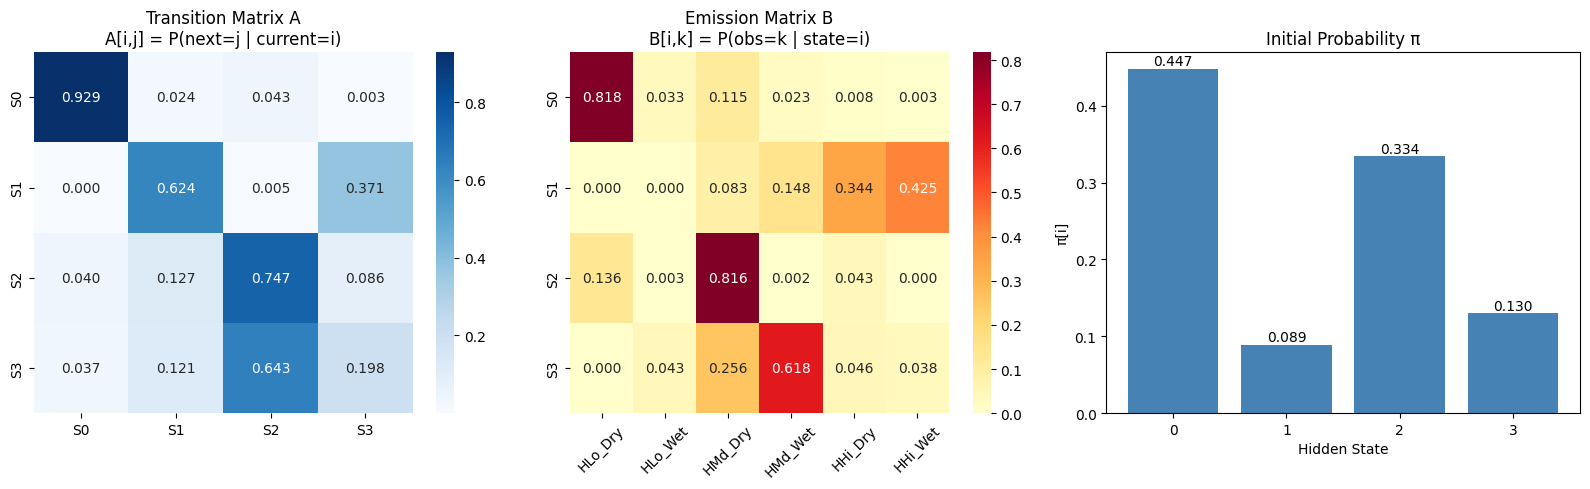

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Transition matrix A
sns.heatmap(model.A, annot=True, fmt='.3f', cmap='Blues', ax=axes[0],
            xticklabels=[f'S{i}' for i in range(N_STATES)],
            yticklabels=[f'S{i}' for i in range(N_STATES)])
axes[0].set_title('Transition Matrix A\nA[i,j] = P(next=j | current=i)')

# Emission matrix B
sns.heatmap(model.B, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1],
            xticklabels=obs_labels,
            yticklabels=[f'S{i}' for i in range(N_STATES)])
axes[1].set_title('Emission Matrix B\nB[i,k] = P(obs=k | state=i)')
axes[1].tick_params(axis='x', rotation=45)

# Initial probability π
axes[2].bar(range(N_STATES), model.pi, color='steelblue')
axes[2].set_title('Initial Probability π')
axes[2].set_xlabel('Hidden State')
axes[2].set_ylabel('π[i]')
axes[2].set_xticks(range(N_STATES))
for i, v in enumerate(model.pi):
    axes[2].text(i, v + 0.005, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig('hmm_params.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Giải mã Viterbi & ánh xạ sang RainTomorrow

In [68]:
# --- Giải mã chuỗi train để tính P(Rain | state) ---
all_train_states = []
for seq in train_seqs:
    _, states = model.viterbi(seq)
    all_train_states.append(states)

train_df_all = train_df_all.copy()
train_df_all['HiddenState'] = np.concatenate(all_train_states)

# Xác suất mưa thực nghiệm theo trạng thái
state_rain_prob = train_df_all.groupby('HiddenState')['RainBin'].mean()

print('P(RainTomorrow=Yes | HiddenState) từ tập train:')
for s, p in state_rain_prob.items():
    rain_icon = '☁' * int(p * 10)
    print(f'  State {s}: {p:.4f}  {rain_icon}')

P(RainTomorrow=Yes | HiddenState) từ tập train:
  State 0: 0.0687  
  State 1: 0.6596  ☁☁☁☁☁☁
  State 2: 0.1378  ☁
  State 3: 0.2021  ☁☁


In [69]:
# Giải mã chuỗi test
all_test_states = []
for seq in test_seqs:
    _, states = model.viterbi(seq)
    all_test_states.append(states)

test_df_all = test_df_all.copy()
test_df_all['HiddenState'] = np.concatenate(all_test_states)

# Direct Mapping: P(Rain | state_t)
test_df_all['RainProb'] = test_df_all['HiddenState'].map(state_rain_prob)
test_df_all['Pred']     = (test_df_all['RainProb'] >= 0.5).astype(int)

print('Mẫu kết quả:')
test_df_all[['Date','Location','Obs','HiddenState','RainProb','Pred','RainBin']].head(6)


Mẫu kết quả:


,Date,Location,Obs,HiddenState,RainProb,Pred,RainBin
0,2015-10-12,Adelaide,2,2,0.137790,0,0
1,2015-10-13,Adelaide,2,2,0.137790,0,0
2,2015-10-14,Adelaide,0,0,0.068727,0,0
3,2015-10-15,Adelaide,0,0,0.068727,0,0
4,2015-10-16,Adelaide,2,0,0.068727,0,1
5,2015-10-17,Adelaide,1,0,0.068727,0,0


## 8. Đánh giá kết quả

In [70]:
y_true = test_df_all['RainBin'].values
y_pred = test_df_all['Pred'].values
y_prob = test_df_all['RainProb'].values

print('=== Direct Mapping (threshold=0.5) ===')
print(classification_report(y_true, y_pred, target_names=['No Rain', 'Rain']))
print(f'ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}')


=== Direct Mapping (threshold=0.5) ===
              precision    recall  f1-score   support

     No Rain       0.87      0.92      0.89     22050
        Rain       0.65      0.51      0.57      6407

    accuracy                           0.83     28457
   macro avg       0.76      0.72      0.73     28457
weighted avg       0.82      0.83      0.82     28457

ROC-AUC: 0.7573


KeyError: 'Pred_direct'

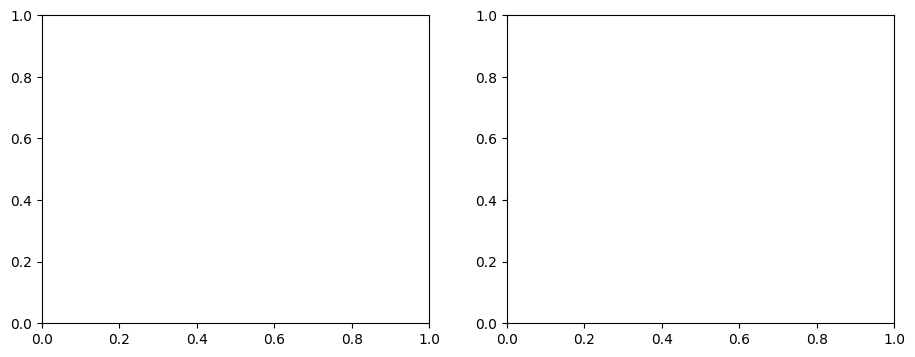

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, col) in zip(axes, [
    ('Direct Mapping', 'Pred_direct'),
    ('Transition Prediction', 'Pred_trans'),
]):
    cm = confusion_matrix(y_true, test_df_all[col].values)
    ConfusionMatrixDisplay(cm, display_labels=['No Rain', 'Rain']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.savefig('hmm_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Visualise hidden states theo thời gian (Sydney)

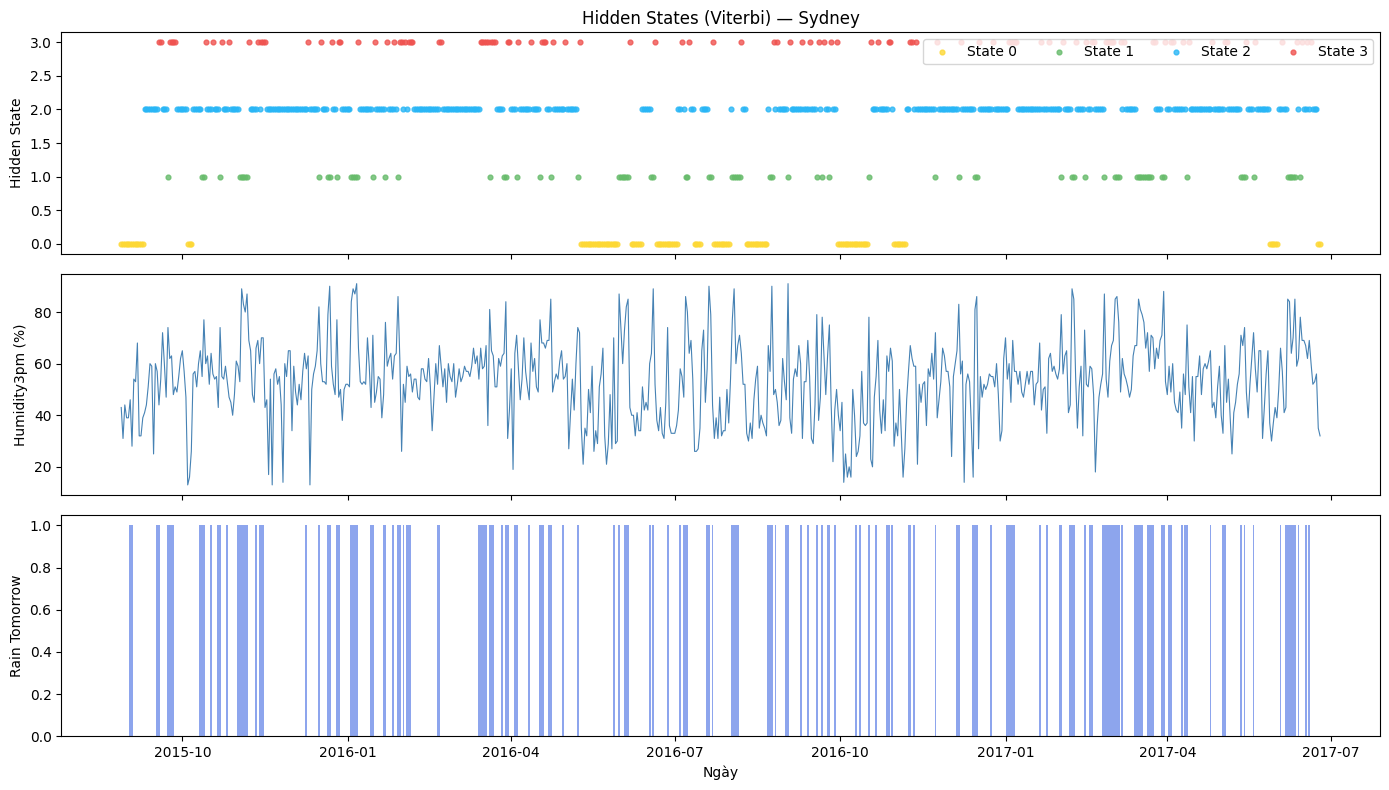

In [ ]:
sydney = test_df_all[test_df_all['Location'] == 'Sydney'].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

colors = ['#FDD835', '#66BB6A', '#29B6F6', '#EF5350']
for state in range(N_STATES):
    mask = sydney['HiddenState'] == state
    axes[0].scatter(sydney.loc[mask, 'Date'], [state]*mask.sum(),
                    c=colors[state], s=12, alpha=0.8, label=f'State {state}')
axes[0].set_ylabel('Hidden State')
axes[0].set_title('Hidden States (Viterbi) — Sydney')
axes[0].legend(loc='upper right', ncol=4)

axes[1].plot(sydney['Date'], sydney['Humidity3pm'], color='steelblue', linewidth=0.8)
axes[1].set_ylabel('Humidity3pm (%)')

rain_days = sydney[sydney['RainBin'] == 1]
axes[2].bar(rain_days['Date'], 1, width=1, color='royalblue', alpha=0.6)
axes[2].set_ylabel('Rain Tomorrow')
axes[2].set_xlabel('Ngày')

plt.tight_layout()
plt.savefig('hmm_timeline.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Dự đoán cho một ngày mới

In [ ]:
def predict_rain_tomorrow(humidity3pm: float, rain_today: int,
                          model, state_rain_prob):
    """
    Args:
        humidity3pm : độ ẩm lúc 3pm (%)
        rain_today  : hôm nay có mưa không? (0=No, 1=Yes)
    """
    h = 0 if humidity3pm <= 40 else (1 if humidity3pm <= 70 else 2)
    obs_sym = np.array([h * 2 + rain_today])

    _, states = model.viterbi(obs_sym)
    current_state = states[0]

    rain_prob = state_rain_prob.get(current_state, 0)

    return {
        'current_state'   : int(current_state),
        'rain_probability': round(float(rain_prob), 4),
        'prediction'      : 'Yes' if rain_prob >= 0.5 else 'No'
    }


# Ví dụ 1: Hôm nay ẩm và có mưa
r1 = predict_rain_tomorrow(75, 1, model, state_rain_prob)
print('Ngày ẩm, hôm nay mưa (Humidity=75%, RainToday=Yes):')
print(f'  State: {r1["current_state"]} | P(Rain) = {r1["rain_probability"]*100:.1f}% | → {r1["prediction"]}')

# Ví dụ 2: Hôm nay khô, không mưa
r2 = predict_rain_tomorrow(30, 0, model, state_rain_prob)
print('Ngày khô, hôm nay không mưa (Humidity=30%, RainToday=No):')
print(f'  State: {r2["current_state"]} | P(Rain) = {r2["rain_probability"]*100:.1f}% | → {r2["prediction"]}')
